# Import Libraries

In [1]:
# 📌 Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')


# Load the Dataset

In [2]:
# 📌 Step 2: Load Dataset
df = pd.read_csv(r"C:\Users\VICTUS\Downloads\Store Item Demand Forecasting Challenge dataset\train.csv")
df.head()


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


# Convert date Column to Date Format

In [3]:
# 📌 Step 3: Convert 'date' to datetime and create time features
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df.head()


,date,store,item,sales,year,month,day,dayofweek
0,2013-01-01,1,1,13,2013,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2
2,2013-01-03,1,1,14,2013,1,3,3
3,2013-01-04,1,1,13,2013,1,4,4
4,2013-01-05,1,1,10,2013,1,5,5


# Create New Time Features

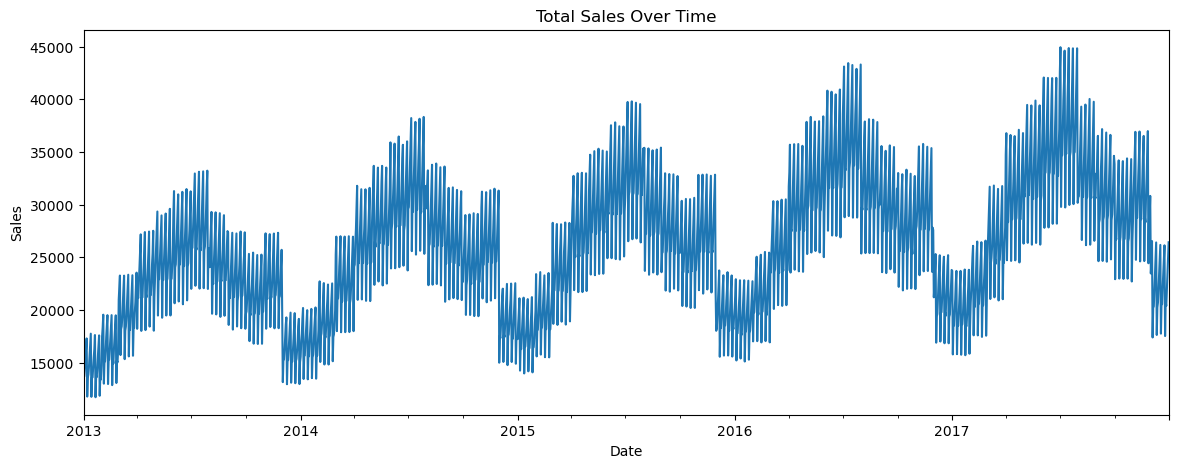

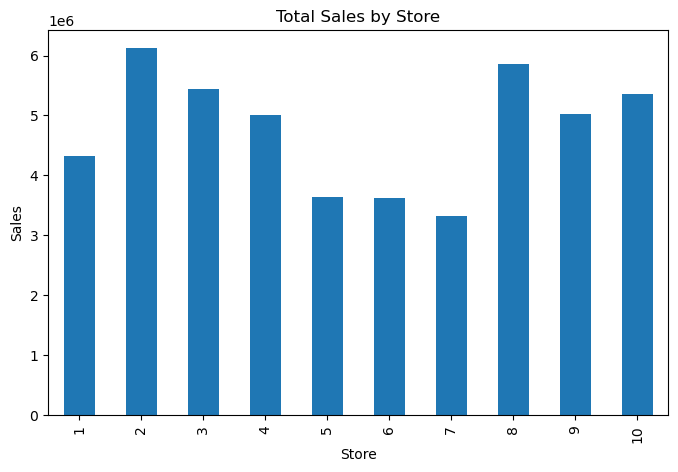

In [4]:
# 📌 Step 4: Exploratory Data Analysis (optional)
df.groupby('date')['sales'].sum().plot(figsize=(14,5), title="Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

df.groupby('store')['sales'].sum().plot(kind='bar', title='Total Sales by Store', figsize=(8,5))
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()


In [5]:
# 📌 Step 5: Prepare Features and Target
features = ['store', 'item', 'year', 'month', 'day', 'dayofweek']
X = df[features]
y = df['sales']

In [7]:
# 📌 Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Prepare Features and Labels for ML Model

In [8]:
# 📌 Step 7: Train Models

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Decision Tree
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

# XGBoost
!pip install xgboost
from xgboost import XGBRegressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))


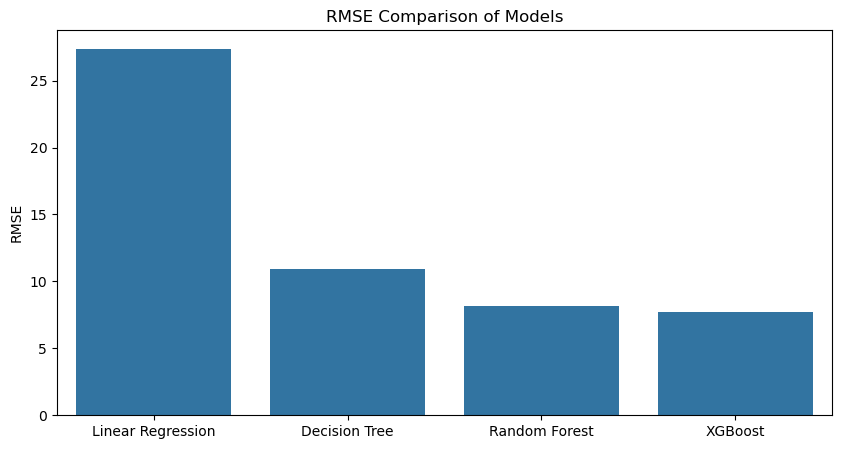

In [9]:
# 📌 Step 8: Compare RMSE of All Models
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
rmses = [lr_rmse, dt_rmse, rf_rmse, xgb_rmse]

plt.figure(figsize=(10,5))
sns.barplot(x=models, y=rmses)
plt.title('RMSE Comparison of Models')
plt.ylabel('RMSE')
plt.show()


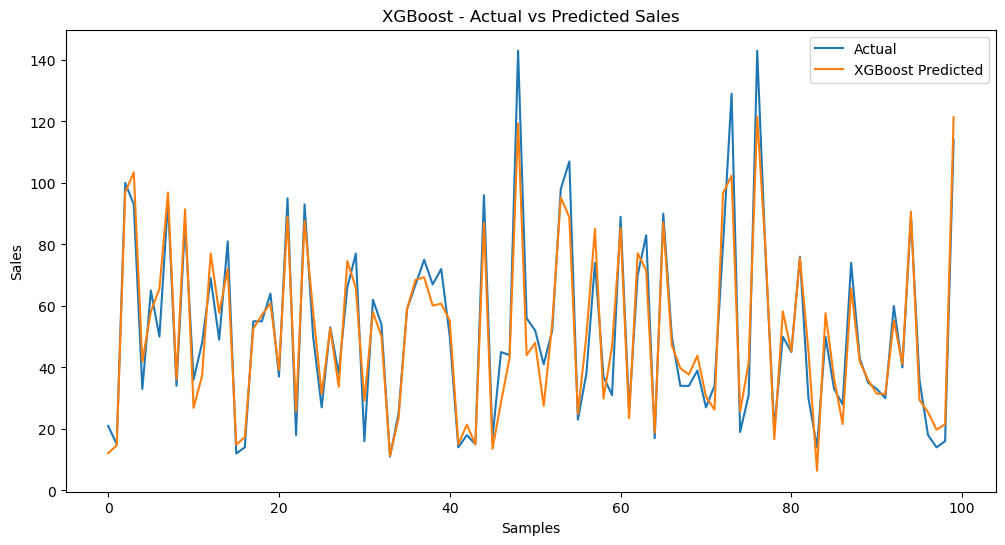

In [10]:
# 📌 Step 9: Visualize Predictions from XGBoost
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(xgb_pred[:100], label='XGBoost Predicted')
plt.title('XGBoost - Actual vs Predicted Sales')
plt.xlabel('Samples')
plt.ylabel('Sales')
plt.legend()
plt.show()


# Save the Best Model

In [11]:
# 📌 Step 10: Save the Best Model
joblib.dump(xgb_model, 'xgboost_demand_forecast_model.pkl')
print("✅ Model saved as xgboost_demand_forecast_model.pkl")


✅ Model saved as xgboost_demand_forecast_model.pkl


In [12]:
# 📌 Step 11: Create test_data_sample.csv with dummy actual_sales (for deployment)
test_sample_dummy = df[features].copy()
test_sample_dummy['actual_sales'] = 0
test_sample_dummy.to_csv("test_data_sample.csv", index=False)
print("📁 test_data_sample.csv saved with dummy actual_sales = 0")


📁 test_data_sample.csv saved with dummy actual_sales = 0


In [13]:
# 📌 Step 12: Create test_data_sample_real.csv with real y_test (for evaluation)
test_sample_real = X_test.copy()
test_sample_real['actual_sales'] = y_test.values
test_sample_real.to_csv("test_data_sample_real.csv", index=False)
print("📁 test_data_sample_real.csv saved with actual sales")


📁 test_data_sample_real.csv saved with actual sales
